<a href="https://colab.research.google.com/github/AthulKrishna9103/ML-projects/blob/main/Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib tqdm

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

Dataset

In [ ]:
def get_dataloader(batch_size=64):

    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    return loader

Diffusion

In [ ]:
class Diffusion:

    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=32, device="cuda"):
        self.noise_steps = noise_steps
        self.device = device

        self.beta = torch.linspace(beta_start, beta_end, noise_steps).to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

        self.img_size = img_size

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]

        noise = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * noise, noise

Timestamp Embedding

In [ ]:
import math

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = time[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

Minimal U-Net

In [ ]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.relu(self.conv1(x))

        time_emb = self.time_mlp(t)
        time_emb = time_emb[:, :, None, None]
        h = h + time_emb

        h = self.relu(self.conv2(h))
        return h


class UNet(nn.Module):
    def __init__(self, time_dim=256):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # down
        self.down1 = Block(3, 64, time_dim)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = Block(64, 128, time_dim)
        self.pool2 = nn.MaxPool2d(2)

        # bottleneck
        self.bot = Block(128, 256, time_dim)

        # up
        self.up1 = nn.Upsample(scale_factor=2)
        self.up_block1 = Block(256 + 128, 128, time_dim)

        self.up2 = nn.Upsample(scale_factor=2)
        self.up_block2 = Block(128 + 64, 64, time_dim)

        self.out = nn.Conv2d(64, 3, 1)

    def forward(self, x, t):
        t = self.time_mlp(t.float())

        d1 = self.down1(x, t)
        d2 = self.down2(self.pool1(d1), t)

        b = self.bot(self.pool2(d2), t)

        u1 = self.up1(b)
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.up_block1(u1, t)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up_block2(u2, t)

        return self.out(u2)

EMA Class

In [ ]:
class EMA:
    def __init__(self, beta=0.995):
        self.beta = beta
        self.step = 0

    def update_model_average(self, ema_model, model):
        for ema_param, param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data = self.beta * ema_param.data + (1 - self.beta) * param.data

    def step_ema(self, ema_model, model):
        self.update_model_average(ema_model, model)
        self.step += 1

Training

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

loader = get_dataloader()

# main model
model = UNet().to(device)

# diffusion
diffusion = Diffusion(device=device)

# optimizer + loss
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
mse = nn.MSELoss()

# EMA setup (NEW)
ema = EMA(0.995)
ema_model = UNet().to(device)
ema_model.load_state_dict(model.state_dict())
ema_model.eval()

UNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU()
  )
  (down1): Block(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_mlp): Linear(in_features=256, out_features=64, bias=True)
    (relu): ReLU()
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): Block(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_mlp): Linear(in_features=256, out_features=128, bias=True)
    (relu): ReLU()
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bot): Block(
    (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(256, 256, kernel_siz

In [ ]:
epochs = 25

for epoch in range(epochs):
    pbar = tqdm(loader)

    for images, _ in pbar:
        images = images.to(device)

        t = diffusion.sample_timesteps(images.shape[0]).to(device)
        x_t, noise = diffusion.noise_images(images, t)

        predicted_noise = model(x_t, t)
        loss = mse(noise, predicted_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ema.step_ema(ema_model, model)

        pbar.set_description(f"epoch {epoch} loss: {loss.item():.4f}")

epoch 24 loss: 0.0143: 100%|██████████| 782/782 [00:31<00:00, 25.12it/s]


Sampling

In [ ]:
@torch.no_grad()
def sample(model, diffusion, n=16):
    model.eval()

    x = torch.randn((n, 3, diffusion.img_size, diffusion.img_size)).to(device)

    for i in reversed(range(1, diffusion.noise_steps)):
        t = (torch.ones(n) * i).long().to(device)

        predicted_noise = model(x, t)

        alpha = diffusion.alpha[t][:, None, None, None]
        alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
        beta = diffusion.beta[t][:, None, None, None]

        if i > 1:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha)
            * (x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise)
            + torch.sqrt(beta) * noise
        )

    model.train()
    return x

Visualize

(np.float64(-0.5), np.float64(137.5), np.float64(137.5), np.float64(-0.5))

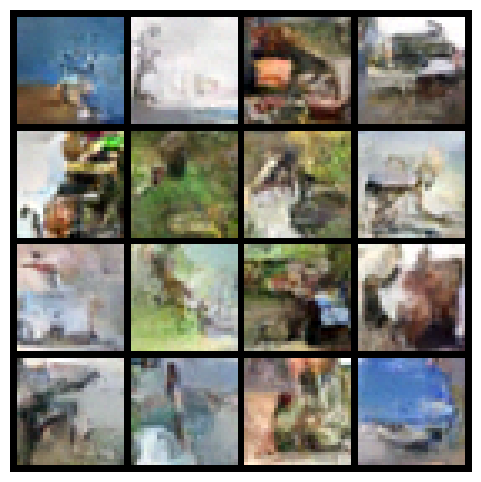

In [ ]:
images = sample(ema_model, diffusion, n=16)
images = (images.clamp(-1, 1) + 1) / 2

grid = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")